### Pré-processamento dos arquivos parquet:

1. Adicionando a coluna de bairro (Borough) a partir do arquivo "taxi_zone_lookup.csv"

2. Removendo coluna "ehail_fee" que não aparece no dicionário de dados e contém somente valores nulos

3. Adicionando outras outras colunas desejadas para análise

In [30]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt

### Configurações

In [31]:
# Caminho da pasta onde estão os arquivos parquet originais a serem pré-processados
PASTA_ENTRADA = '../data/green'

# Caminho do arquivo CSV contendo a relação entre LocationID e Borough (bairro)
ARQUIVO_CSV = '../data/taxi_zone_lookup.csv'

# Pasta onde o arquivo processado que será criado
PASTA_ARQUIVO_PROCESSADO = '../data/parquet_processado'

# Nome do novo arquivo processado que será criado
NOME_ARQUIVO_PROCESSADO = 'green_tripdata_2025.parquet'

CAMINHO_ARQUIVO_PROCESSADO = PASTA_ARQUIVO_PROCESSADO + "/" + NOME_ARQUIVO_PROCESSADO

In [32]:
# 1. Cria a pasta de saída caso ela ainda não exista
if not os.path.exists(PASTA_ARQUIVO_PROCESSADO):
    os.makedirs(PASTA_ARQUIVO_PROCESSADO)
    print(f"Pasta de saída '{PASTA_ARQUIVO_PROCESSADO}' criada.")

print(f"Carregando o arquivo de bairros: {ARQUIVO_CSV}...")
# 2. Carrega o CSV contendo os bairros
try:
    df_zonas = pd.read_csv(ARQUIVO_CSV)[['LocationID', 'Borough']]
except FileNotFoundError:
    print(f"Erro: O arquivo '{ARQUIVO_CSV}' não foi encontrado.")

Carregando o arquivo de bairros: ../data/taxi_zone_lookup.csv...


In [33]:
# 3. Busca todos os arquivos .parquet na pasta de entrada
padrao_busca = os.path.join(PASTA_ENTRADA, '*.parquet')
arquivos_parquet = glob.glob(padrao_busca)

if not arquivos_parquet:
    print(f"Nenhum arquivo parquet encontrado na pasta '{PASTA_ENTRADA}'.")
else:
    print(f"Encontrados {len(arquivos_parquet)} arquivo(s) Parquet. Iniciando processamento...")

    df_viagens_completo = pd.DataFrame()
    # 4. Loop por cada arquivo encontrado
    for caminho_arquivo in arquivos_parquet:
        nome_arquivo = os.path.basename(caminho_arquivo)

        # Lê o parquet atual
        df_viagens = pd.read_parquet(caminho_arquivo)

        # Merge de Embarque (PULocationID)
        df_viagens = df_viagens.merge(
            df_zonas,
            how='left',
            left_on='PULocationID',
            right_on='LocationID'
        )
        df_viagens = df_viagens.rename(columns={'Borough': 'pu_borough'})
        df_viagens = df_viagens.drop(columns=['LocationID'])

        # Merge de Desembarque (DOLocationID)
        df_viagens = df_viagens.merge(
            df_zonas,
            how='left',
            left_on='DOLocationID',
            right_on='LocationID'
        )
        df_viagens = df_viagens.rename(columns={'Borough': 'do_borough'})
        df_viagens = df_viagens.drop(columns=['LocationID'])

        # Preenche o valor N/A nas colunas de bairro com NaN
        # O valor N/A é previsto e significa que o bairro não foi identificado
        # Após o merge, por algum motivo os N/A se tornam NaN
        df_viagens['pu_borough'] = df_viagens['pu_borough'].fillna('N/A')
        df_viagens['do_borough'] = df_viagens['do_borough'].fillna('N/A')

        df_viagens_completo = pd.concat([df_viagens_completo, df_viagens])
print("Arquivos parquet processados!")

Encontrados 12 arquivo(s) Parquet. Iniciando processamento...
Arquivos parquet processados!


### Adiciona coluna de duração da viagem em minutos

In [34]:
# Calcula a duração da viagem em minutos e adiciona coluna 'trip_duration_minutes'
df_viagens_completo['trip_duration_minutes'] = (df_viagens_completo['lpep_dropoff_datetime'] - df_viagens_completo['lpep_pickup_datetime']).dt.total_seconds() / 60

### Analisando dataframe

In [35]:
colunas_relevantes = [
    'lpep_pickup_datetime',
    'lpep_dropoff_datetime',
    'PULocationID',
    'DOLocationID',
    'trip_distance',
    'fare_amount',
    'extra',
    'tip_amount',
    'payment_type',
    'pu_borough',
    'do_borough',
    'trip_duration_minutes'
]

df_viagens_completo[
    [col for col in colunas_relevantes if col in df_viagens_completo.columns]
].describe(include='all')


,lpep_pickup_datetime,lpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,extra,tip_amount,payment_type,pu_borough,do_borough,trip_duration_minutes
count,591375,591375,591375.000000,591375.000000,591375.000000,591375.000000,591375.000000,591375.000000,541495.000000,591375,591375,591375.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,8,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manhattan,Manhattan,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,351832,357046,NaN
mean,2025-06-30 05:29:22.003692,2025-06-30 05:50:22.027086,96.782483,142.740777,19.023835,18.088240,0.885275,2.661700,1.260804,NaN,NaN,21.000390
min,2008-12-31 15:13:04,2008-12-31 17:25:57,1.000000,1.000000,0.000000,-470.600000,-6.000000,-100.000000,1.000000,NaN,NaN,-48.833333
25%,2025-04-01 18:02:59,2025-04-01 18:22:58.500000,74.000000,74.000000,1.210000,9.300000,0.000000,0.000000,1.000000,NaN,NaN,7.966667
50%,2025-06-26 06:18:54,2025-06-26 06:40:33,75.000000,140.000000,1.980000,13.500000,0.000000,2.080000,1.000000,NaN,NaN,12.500000
75%,2025-09-29 04:33:15,2025-09-29 05:31:46.500000,97.000000,230.000000,3.510000,20.500000,1.000000,3.920000,1.000000,NaN,NaN,19.216667
max,2026-01-01 21:09:39,2026-01-01 21:49:52,265.000000,265.000000,262315.940000,1086.600000,12.500000,350.000000,5.000000,NaN,NaN,1500.766667


In [36]:
df_viagens_completo.info()

<class 'pandas.DataFrame'>
Index: 591375 entries, 0 to 48235
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               591375 non-null  int32         
 1   lpep_pickup_datetime   591375 non-null  datetime64[us]
 2   lpep_dropoff_datetime  591375 non-null  datetime64[us]
 3   store_and_fwd_flag     541495 non-null  str           
 4   RatecodeID             541495 non-null  float64       
 5   PULocationID           591375 non-null  int32         
 6   DOLocationID           591375 non-null  int32         
 7   passenger_count        541495 non-null  float64       
 8   trip_distance          591375 non-null  float64       
 9   fare_amount            591375 non-null  float64       
 10  extra                  591375 non-null  float64       
 11  mta_tax                591375 non-null  float64       
 12  tip_amount             591375 non-null  float64       
 13  t

In [37]:
resumo_por_pu = (
    df_viagens_completo
    .groupby('pu_borough')
    .agg(
        viagens=('pu_borough', 'size'),
        distancia_max=('trip_distance', 'max'),
        distancia_min=('trip_distance', 'min'),
        duracao_max=('trip_duration_minutes', 'max'),
        duracao_min=('trip_duration_minutes', 'min'),
        tarifa_max=('fare_amount', 'max'),
        tarifa_min=('fare_amount', 'min'),
        gorjeta_min=('tip_amount', 'min')
    )
    .reset_index()
    .sort_values('viagens', ascending=False)
)

resumo_por_pu

,pu_borough,viagens,distancia_max,distancia_min,duracao_max,duracao_min,tarifa_max,tarifa_min,gorjeta_min
3,Manhattan,351832,262315.94,0.0,1439.883333,-0.966667,745.0,-240.0,0.0
5,Queens,137685,89615.27,0.0,1500.766667,-48.833333,998.0,-470.6,-100.0
1,Brooklyn,88411,177505.24,0.0,1439.883333,-47.266667,993.5,-200.0,0.0
0,Bronx,11518,110301.96,0.0,1439.500000,-0.966667,1086.6,-150.0,0.0
7,Unknown,1410,30.40,0.0,122.816667,0.000000,300.0,-70.0,-0.9
4,N/A,459,61.43,0.0,1400.700000,0.000000,480.0,-223.0,-4.0
6,Staten Island,46,43.15,0.0,120.516667,0.016667,150.0,0.0,0.0
2,EWR,14,0.08,0.0,3.083333,0.033333,175.0,3.0,0.0


In [38]:
resumo_por_do = (
    df_viagens_completo
    .groupby('do_borough')
    .agg(
        viagens=('do_borough', 'size'),
        distancia_max=('trip_distance', 'max'),
        distancia_min=('trip_distance', 'min'),
        duracao_max=('trip_duration_minutes', 'max'),
        duracao_min=('trip_duration_minutes', 'min'),
        tarifa_max=('fare_amount', 'max'),
        tarifa_min=('fare_amount', 'min'),
        gorjeta_min=('tip_amount', 'min')
    )
    .reset_index()
    .sort_values('viagens', ascending=False)
)

resumo_por_do

,do_borough,viagens,distancia_max,distancia_min,duracao_max,duracao_min,tarifa_max,tarifa_min,gorjeta_min
3,Manhattan,357046,262315.94,0.0,1439.883333,-0.966667,350.00,-240.0,0.0
5,Queens,132264,249852.24,0.0,1500.766667,-48.833333,998.00,-300.0,-100.0
1,Brooklyn,75039,177505.24,0.0,1439.233333,-47.266667,993.50,-470.6,0.0
0,Bronx,17727,115373.76,0.0,1439.033333,-0.966667,336.20,-150.0,0.0
7,Unknown,6279,44.22,0.0,1397.766667,0.000000,300.00,-230.0,-4.0
4,N/A,2550,39276.53,0.0,1432.733333,0.000000,1086.60,-223.0,0.0
2,EWR,308,97092.05,0.0,1396.983333,0.050000,250.00,14.0,0.0
6,Staten Island,162,42800.20,0.0,1427.100000,-0.200000,225.98,0.0,0.0


### Visualizando viagens por bairro

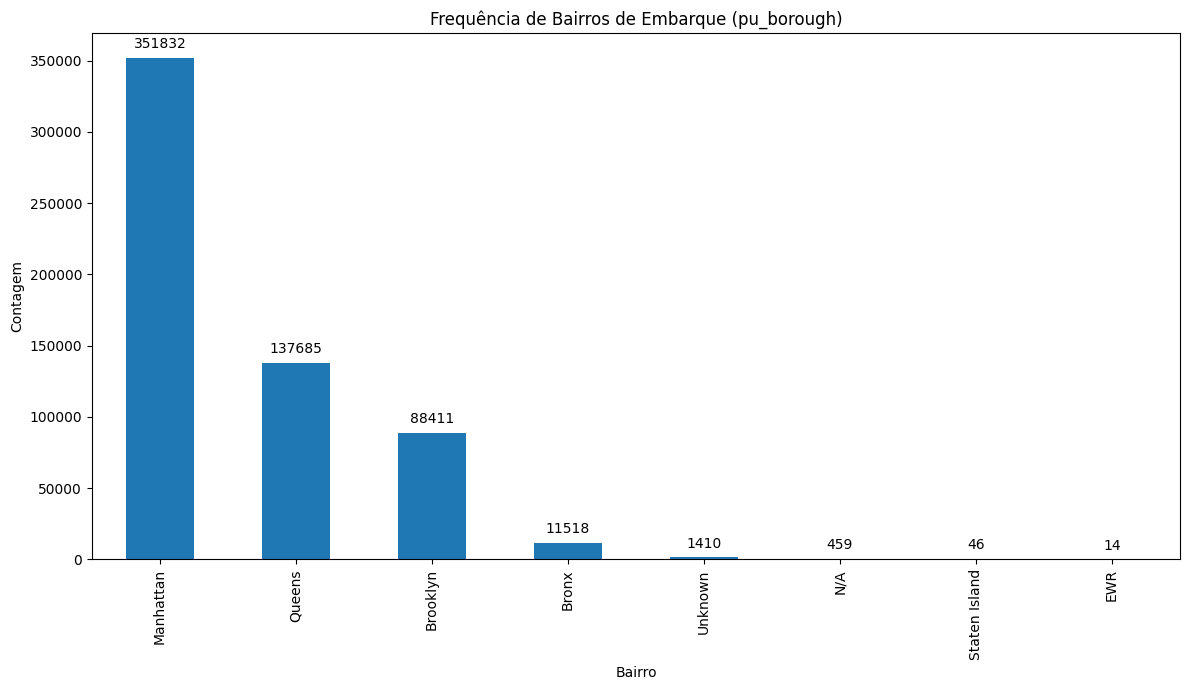

In [39]:
# Plot para 'pu_borough' (pickup borough)
plt.figure(figsize=(12, 7))
ax1 = df_viagens_completo['pu_borough'].value_counts().plot(kind='bar', title='Frequência de Bairros de Embarque (pu_borough)')
plt.ylabel('Contagem')
plt.xlabel('Bairro')

# Adiciona os valores nas barras
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

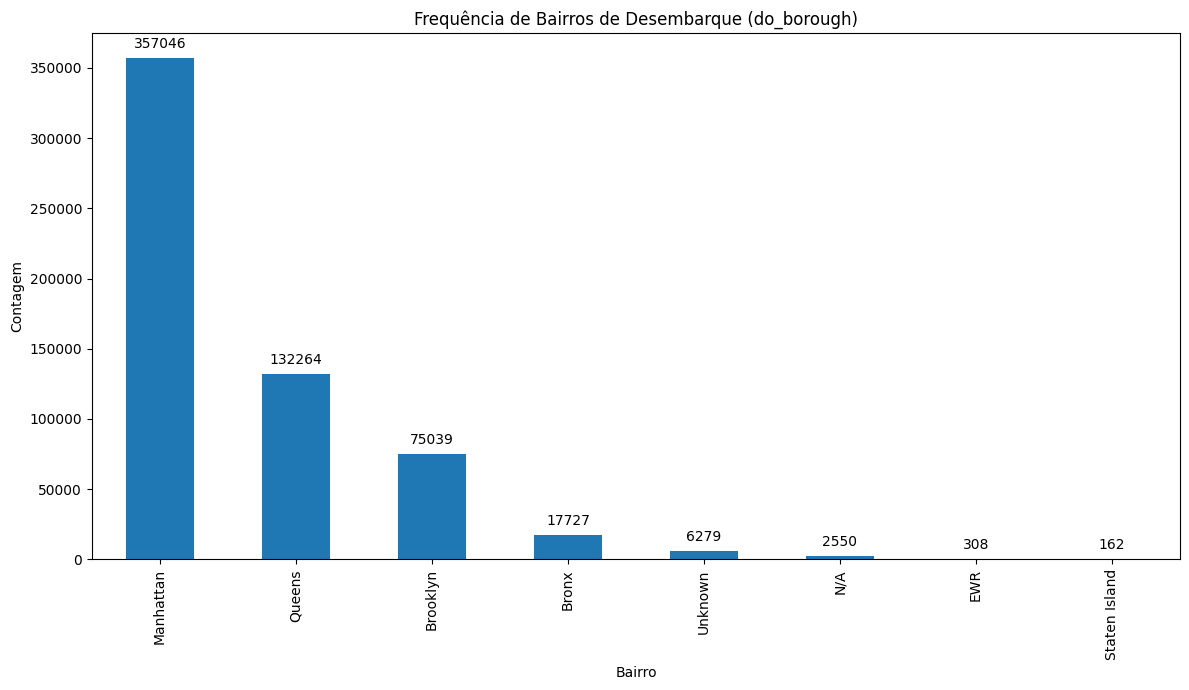

In [40]:
# Plot para 'do_borough' (dropoff borough)
plt.figure(figsize=(12, 7))
ax2 = df_viagens_completo['do_borough'].value_counts().plot(kind='bar', title='Frequência de Bairros de Desembarque (do_borough)')
plt.ylabel('Contagem')
plt.xlabel('Bairro')

# Adiciona os valores nas barras
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Calculando métricas por bairro

In [41]:
# Calcula métricas médias por minuto
df_metricas = df_viagens_completo.copy()
df_metricas['fare_amount_per_minute'] = df_metricas['fare_amount'] / df_metricas['trip_duration_minutes']
df_metricas['extra_per_minute'] = df_metricas['extra'] / df_metricas['trip_duration_minutes']
df_metricas['tip_amount_per_minute'] = df_metricas['tip_amount'] / df_metricas['trip_duration_minutes']

# Tabela 1: médias agrupadas por bairro de embarque
df_pu_summary = df_metricas.groupby('pu_borough').agg(
    mean_fare_per_minute=('fare_amount_per_minute', 'mean'),
    mean_extra_per_minute=('extra_per_minute', 'mean'),
    tip_per_minute=('tip_amount_per_minute', 'mean')
).reset_index()
df_pu_summary['mean_earn'] = df_pu_summary[['mean_fare_per_minute', 'mean_extra_per_minute', 'tip_per_minute']].sum(axis=1)

print("Médias por Bairro de Embarque (Pickup Borough):")
display(df_pu_summary.sort_values(by='mean_earn', ascending=False))

# Tabela 2: médias agrupadas por bairro de desembarque
df_do_summary = df_metricas.groupby('do_borough').agg(
    mean_fare_per_minute=('fare_amount_per_minute', 'mean'),
    mean_extra_per_minute=('extra_per_minute', 'mean'),
    tip_per_minute=('tip_amount_per_minute', 'mean')
).reset_index()
df_do_summary['mean_earn'] = df_do_summary[['mean_fare_per_minute', 'mean_extra_per_minute', 'tip_per_minute']].sum(axis=1)

print("\nMédias por Bairro de Desembarque (Dropoff Borough):")
display(df_do_summary.sort_values(by='mean_earn', ascending=False))

Médias por Bairro de Embarque (Pickup Borough):


,pu_borough,mean_fare_per_minute,mean_extra_per_minute,tip_per_minute,mean_earn
0,Bronx,inf,inf,inf,inf
1,Brooklyn,inf,inf,inf,inf
3,Manhattan,inf,inf,inf,inf
4,N/A,inf,inf,inf,inf
7,Unknown,NaN,NaN,inf,inf
5,Queens,NaN,inf,inf,inf
2,EWR,1699.418068,0.000000,246.737662,1946.155731
6,Staten Island,155.801993,0.357828,42.761865,198.921687



Médias por Bairro de Desembarque (Dropoff Borough):


,do_borough,mean_fare_per_minute,mean_extra_per_minute,tip_per_minute,mean_earn
0,Bronx,inf,0.061067,inf,inf
1,Brooklyn,inf,inf,inf,inf
3,Manhattan,inf,inf,inf,inf
4,N/A,inf,inf,inf,inf
7,Unknown,NaN,NaN,inf,inf
5,Queens,inf,inf,inf,inf
6,Staten Island,39.966017,0.104902,12.237551,52.308470
2,EWR,36.675894,0.004894,3.221756,39.902544


### Limpeza de dados

In [42]:
print(f"Shape do DataFrame antes da remoção: {df_viagens_completo.shape}")

# 1) Remover colunas não utilizadas
df_viagens_completo = df_viagens_completo.drop(
    columns=[
        'VendorID',
        'store_and_fwd_flag',
        'RatecodeID',
        'passenger_count',
        'trip_type',
        'congestion_surcharge',
        'cbd_congestion_fee',
        'ehail_fee',
        'tolls_amount',
        'total_amount',
        'improvement_surcharge',
        'mta_tax'
    ]
)

# 2) Remover linhas onde pu_borough ou do_borough é 'EWR', 'Staten Island', 'N/A' ou 'Unknown'
df_viagens_completo = df_viagens_completo[
    ~((df_viagens_completo['pu_borough'].isin(['EWR', 'Staten Island', 'N/A', 'Unknown'])) |
    (df_viagens_completo['do_borough'].isin(['EWR', 'Staten Island', 'N/A', 'Unknown'])))
]

# 3) Remover trip_duration_minutes <= 1 e >= 120 minutos
df_viagens_completo = df_viagens_completo[
    (df_viagens_completo['trip_duration_minutes'] > 1) &
    (df_viagens_completo['trip_duration_minutes'] < 120)
]

# 4) Remover trip_distance <= 0.1 e >= 50 milhas
df_viagens_completo = df_viagens_completo[
    (df_viagens_completo['trip_distance'] > 0.1) &
    (df_viagens_completo['trip_distance'] < 50)
]

# 5) Remover fare_amount <= 2.5 dólares
df_viagens_completo = df_viagens_completo[df_viagens_completo['fare_amount'] > 2.5]

# 6) Definir 'tip_amount' como NaN para 'payment_type' diferente de 1.0 (Credit card)
# Motivo: gorjeta só é computada quando o pagamento é por Credit card
df_viagens_completo.loc[df_viagens_completo['payment_type'] != 1.0, 'tip_amount'] = None

print(f"\nShape do DataFrame depois da remoção: {df_viagens_completo.shape}")

Shape do DataFrame antes da remoção: (591375, 24)

Shape do DataFrame depois da remoção: (544171, 12)


### Analisando dataframe após limpeza

In [43]:
colunas_relevantes = [
    'lpep_pickup_datetime',
    'lpep_dropoff_datetime',
    'PULocationID',
    'DOLocationID',
    'trip_distance',
    'fare_amount',
    'extra',
    'tip_amount',
    'payment_type',
    'pu_borough',
    'do_borough',
    'trip_duration_minutes'
]

df_viagens_completo[
    [col for col in colunas_relevantes if col in df_viagens_completo.columns]
].describe(include='all')


,lpep_pickup_datetime,lpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,extra,tip_amount,payment_type,pu_borough,do_borough,trip_duration_minutes
count,544171,544171,544171.000000,544171.000000,544171.000000,544171.000000,544171.000000,380361.000000,501953.000000,544171,544171,544171.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manhattan,Manhattan,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,338743,344793,NaN
mean,2025-07-01 01:23:32.316582,2025-07-01 01:39:17.504128,94.720160,142.137536,3.112065,17.525843,0.932435,3.700833,1.245268,NaN,NaN,15.753126
min,2024-12-29 01:23:41,2024-12-29 01:41:08,3.000000,2.000000,0.110000,2.550000,0.000000,0.000000,1.000000,NaN,NaN,1.016667
25%,2025-04-02 15:03:10,2025-04-02 15:17:35.500000,74.000000,74.000000,1.320000,9.300000,0.000000,2.000000,1.000000,NaN,NaN,8.433333
50%,2025-06-27 17:00:29,2025-06-27 17:17:20,75.000000,140.000000,2.070000,13.500000,0.000000,3.060000,1.000000,NaN,NaN,12.716667
75%,2025-09-29 17:17:21.500000,2025-09-29 17:36:32.500000,97.000000,229.000000,3.570000,20.000000,2.500000,4.670000,1.000000,NaN,NaN,19.083333
max,2026-01-01 21:09:39,2026-01-01 21:16:23,263.000000,263.000000,48.480000,975.000000,12.500000,350.000000,5.000000,NaN,NaN,119.983333


In [44]:
df_viagens_completo.info()

<class 'pandas.DataFrame'>
Index: 544171 entries, 0 to 48235
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   lpep_pickup_datetime   544171 non-null  datetime64[us]
 1   lpep_dropoff_datetime  544171 non-null  datetime64[us]
 2   PULocationID           544171 non-null  int32         
 3   DOLocationID           544171 non-null  int32         
 4   trip_distance          544171 non-null  float64       
 5   fare_amount            544171 non-null  float64       
 6   extra                  544171 non-null  float64       
 7   tip_amount             380361 non-null  float64       
 8   payment_type           501953 non-null  float64       
 9   pu_borough             544171 non-null  str           
 10  do_borough             544171 non-null  str           
 11  trip_duration_minutes  544171 non-null  float64       
dtypes: datetime64[us](2), float64(6), int32(2), str(2)
memory usa

In [45]:
resumo_por_pu = (
    df_viagens_completo
    .groupby('pu_borough')
    .agg(
        viagens=('pu_borough', 'size'),
        distancia_max=('trip_distance', 'max'),
        distancia_min=('trip_distance', 'min'),
        duracao_max=('trip_duration_minutes', 'max'),
        duracao_min=('trip_duration_minutes', 'min'),
        tarifa_max=('fare_amount', 'max'),
        tarifa_min=('fare_amount', 'min'),
        gorjeta_min=('tip_amount', 'min')
    )
    .reset_index()
    .sort_values('viagens', ascending=False)
)

resumo_por_pu

,pu_borough,viagens,distancia_max,distancia_min,duracao_max,duracao_min,tarifa_max,tarifa_min,gorjeta_min
2,Manhattan,338743,44.18,0.11,119.983333,1.016667,250.01,2.90,0.0
3,Queens,120013,47.34,0.11,119.983333,1.016667,975.00,2.55,0.0
1,Brooklyn,77476,48.48,0.11,119.950000,1.016667,200.00,2.90,0.0
0,Bronx,7939,33.94,0.11,119.950000,1.016667,180.00,2.90,0.0


In [46]:
resumo_por_do = (
    df_viagens_completo
    .groupby('do_borough')
    .agg(
        viagens=('do_borough', 'size'),
        distancia_max=('trip_distance', 'max'),
        distancia_min=('trip_distance', 'min'),
        duracao_max=('trip_duration_minutes', 'max'),
        duracao_min=('trip_duration_minutes', 'min'),
        tarifa_max=('fare_amount', 'max'),
        tarifa_min=('fare_amount', 'min'),
        gorjeta_min=('tip_amount', 'min')
    )
    .reset_index()
    .sort_values('viagens', ascending=False)
)

resumo_por_do

,do_borough,viagens,distancia_max,distancia_min,duracao_max,duracao_min,tarifa_max,tarifa_min,gorjeta_min
2,Manhattan,344793,42.40,0.11,119.950000,1.016667,350.00,2.90,0.0
3,Queens,118544,47.34,0.11,119.983333,1.016667,975.00,2.55,0.0
1,Brooklyn,66196,48.48,0.11,119.983333,1.016667,200.00,2.90,0.0
0,Bronx,14638,39.91,0.11,119.966667,1.016667,250.01,2.90,0.0


### Visualizando viagens por bairro após limpeza

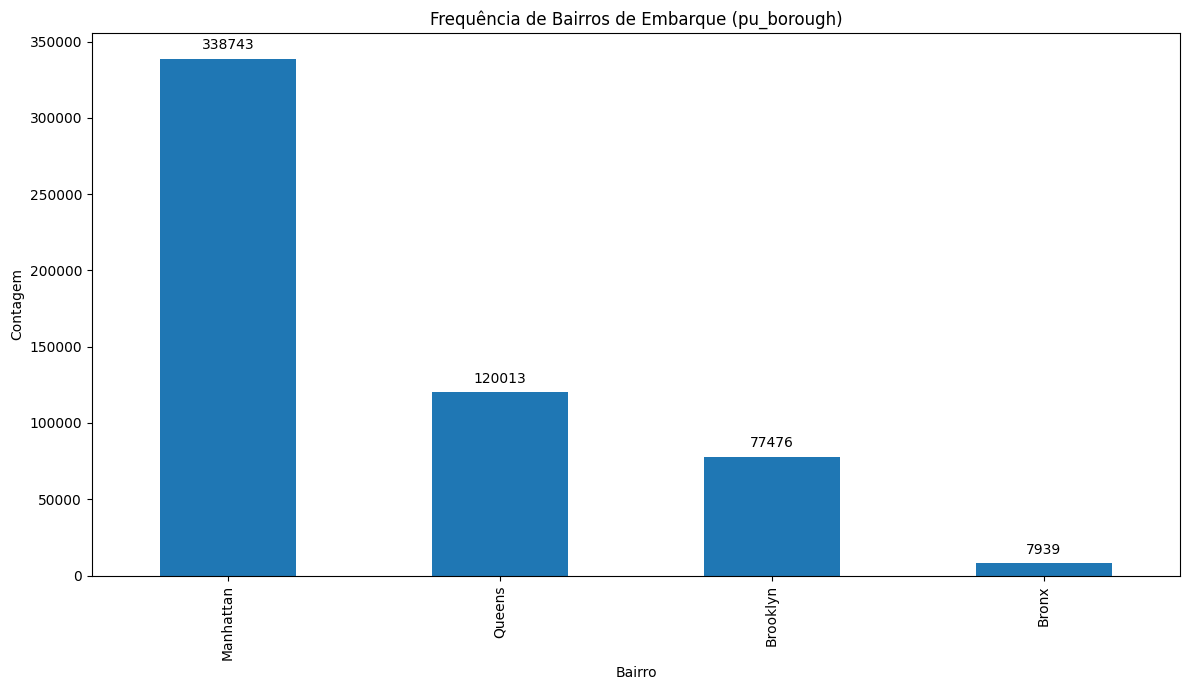

In [47]:
# Verificando corretude dos dados de bairro
# Para plotar dados categóricos, precisamos contar a frequência de cada categoria

# Plot para 'pu_borough' (pickup borough)
plt.figure(figsize=(12, 7))
ax1 = df_viagens_completo['pu_borough'].value_counts().plot(kind='bar', title='Frequência de Bairros de Embarque (pu_borough)')
plt.ylabel('Contagem')
plt.xlabel('Bairro')

# Adiciona os valores nas barras
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

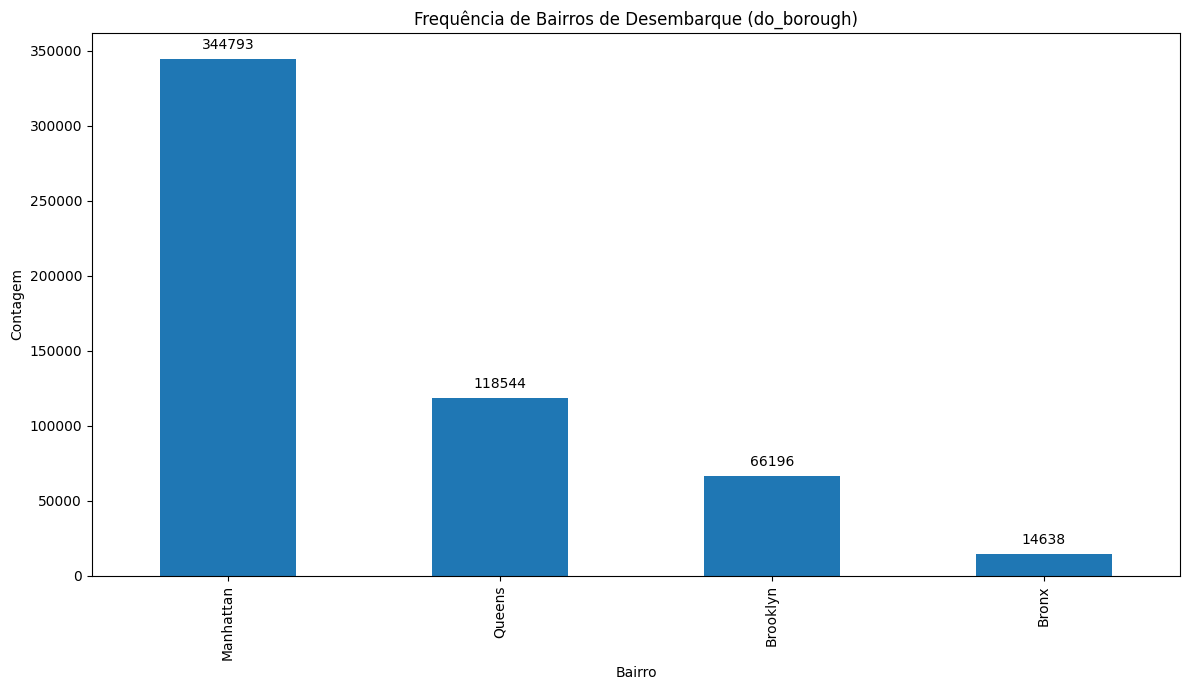

In [48]:
# Plot para 'do_borough' (dropoff borough)
plt.figure(figsize=(12, 7))
ax2 = df_viagens_completo['do_borough'].value_counts().plot(kind='bar', title='Frequência de Bairros de Desembarque (do_borough)')
plt.ylabel('Contagem')
plt.xlabel('Bairro')

# Adiciona os valores nas barras
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Recalculando métricas por bairro após limpeza

In [49]:
# Calcula métricas médias por minuto
df_metricas = df_viagens_completo.copy()
df_metricas['fare_amount_per_minute'] = df_metricas['fare_amount'] / df_metricas['trip_duration_minutes']
df_metricas['extra_per_minute'] = df_metricas['extra'] / df_metricas['trip_duration_minutes']
df_metricas['tip_amount_per_minute'] = df_metricas['tip_amount'] / df_metricas['trip_duration_minutes']

# Tabela 1: médias agrupadas por bairro de embarque
df_pu_summary = df_metricas.groupby('pu_borough').agg(
    mean_fare_per_minute=('fare_amount_per_minute', 'mean'),
    mean_extra_per_minute=('extra_per_minute', 'mean'),
    tip_per_minute=('tip_amount_per_minute', 'mean')
).reset_index()
df_pu_summary['mean_earn'] = df_pu_summary[['mean_fare_per_minute', 'mean_extra_per_minute', 'tip_per_minute']].sum(axis=1)

print("Médias por Bairro de Embarque (Pickup Borough):")
display(df_pu_summary.sort_values(by='mean_earn', ascending=False))

# Tabela 2: médias agrupadas por bairro de desembarque
df_do_summary = df_metricas.groupby('do_borough').agg(
    mean_fare_per_minute=('fare_amount_per_minute', 'mean'),
    mean_extra_per_minute=('extra_per_minute', 'mean'),
    tip_per_minute=('tip_amount_per_minute', 'mean')
).reset_index()
df_do_summary['mean_earn'] = df_do_summary[['mean_fare_per_minute', 'mean_extra_per_minute', 'tip_per_minute']].sum(axis=1)

print("\nMédias por Bairro de Desembarque (Dropoff Borough):")
display(df_do_summary.sort_values(by='mean_earn', ascending=False))

Médias por Bairro de Embarque (Pickup Borough):


,pu_borough,mean_fare_per_minute,mean_extra_per_minute,tip_per_minute,mean_earn
3,Queens,1.442277,0.116789,0.307952,1.867018
0,Bronx,1.196349,0.034793,0.401835,1.632977
1,Brooklyn,1.269198,0.066430,0.285518,1.621145
2,Manhattan,1.201589,0.088368,0.280027,1.569983



Médias por Bairro de Desembarque (Dropoff Borough):


,do_borough,mean_fare_per_minute,mean_extra_per_minute,tip_per_minute,mean_earn
3,Queens,1.437417,0.128703,0.318273,1.884394
2,Manhattan,1.218600,0.084279,0.280261,1.583140
1,Brooklyn,1.217170,0.068333,0.277621,1.563123
0,Bronx,1.148955,0.036461,0.252607,1.438022


### Salvando resultado para arquivo parquet

In [50]:
# Salva o resultado
df_viagens_completo.to_parquet(CAMINHO_ARQUIVO_PROCESSADO, index=False)
print(f"   Salvo com sucesso em: {CAMINHO_ARQUIVO_PROCESSADO}")

   Salvo com sucesso em: ../data/parquet_processado/green_tripdata_2025.parquet
